# Chest X-Ray Classification using VGG16 + XGBoost

This experiment combines deep feature extraction using VGG16 with XGBoost classification.

VGG16 is used as a pretrained feature extractor to obtain high-level image representations, while XGBoost performs the final classification between Normal and Pneumonia chest X-ray images.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

print("Libraries imported successfully.")

I0000 00:00:1781245226.967003    2888 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully.


## Dataset Loading

The Chest X-Ray dataset is loaded from the training and testing folders.

Images will be resized to 224×224 pixels and converted to RGB format because VGG16 expects three-channel RGB images as input.

In [2]:
train_normal_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/train/NORMAL"
train_pneumonia_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/train/PNEUMONIA"

test_normal_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/test/NORMAL"
test_pneumonia_path = "/mnt/c/ML Projects/Medical-Image-Classification-Projects/Exersize-2(ChestXRay)/archive/chest_xray/test/PNEUMONIA"

print("Dataset paths loaded successfully.")

Dataset paths loaded successfully.


## Image Loading

Images are loaded from the dataset folders, resized to 224×224 pixels, converted to RGB format, and assigned labels.

Label Encoding:

- 0 → Normal
- 1 → Pneumonia

In [3]:
def load_images(folder_path, label):

    images = []
    labels = []

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = cv2.resize(
            image,
            (224, 224)
        )

        images.append(image)
        labels.append(label)

    return images, labels

## Dataset Creation

The Normal and Pneumonia images are combined into training and testing datasets.

The resulting images are stored as NumPy arrays for VGG16 feature extraction.

In [4]:
normal_train_images, normal_train_labels = load_images(
    train_normal_path,
    0
)

pneumonia_train_images, pneumonia_train_labels = load_images(
    train_pneumonia_path,
    1
)

normal_test_images, normal_test_labels = load_images(
    test_normal_path,
    0
)

pneumonia_test_images, pneumonia_test_labels = load_images(
    test_pneumonia_path,
    1
)

print("Images loaded successfully.")

Images loaded successfully.


In [5]:
xtrain = np.array(
    normal_train_images + pneumonia_train_images
)

ytrain = np.array(
    normal_train_labels + pneumonia_train_labels
)

xtest = np.array(
    normal_test_images + pneumonia_test_images
)

ytest = np.array(
    normal_test_labels + pneumonia_test_labels
)

print("Training Dataset Shape:", xtrain.shape)
print("Training Labels Shape :", ytrain.shape)

print("Testing Dataset Shape :", xtest.shape)
print("Testing Labels Shape  :", ytest.shape)   

Training Dataset Shape: (5216, 224, 224, 3)
Training Labels Shape : (5216,)
Testing Dataset Shape : (624, 224, 224, 3)
Testing Labels Shape  : (624,)


## VGG16 Preprocessing

The images are preprocessed using the VGG16 preprocessing function.

This transforms pixel values into the format expected by the pretrained VGG16 network.

In [6]:
xtrain_vgg = preprocess_input(
    xtrain.copy()
)

xtest_vgg = preprocess_input(
    xtest.copy()
)

print("Training Shape:", xtrain_vgg.shape)
print("Testing Shape :", xtest_vgg.shape)

Training Shape: (5216, 224, 224, 3)
Testing Shape : (624, 224, 224, 3)


## VGG16 Feature Extractor

A pretrained VGG16 network is loaded using ImageNet weights.

The final classification layers are removed, allowing the network to be used solely as a deep feature extractor.

In [8]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

feature_extractor = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("VGG16 feature extractor loaded successfully.")

W0000 00:00:1781245531.788907    2888 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


VGG16 feature extractor loaded successfully.


## Deep Feature Extraction

The preprocessed images are passed through the VGG16 feature extractor.

The resulting feature maps contain high-level image representations learned from ImageNet.

In [9]:
print("Extracting training features...")

xtrain_features = feature_extractor.predict(
    xtrain_vgg,
    batch_size=32,
    verbose=1
)

print("Extracting testing features...")

xtest_features = feature_extractor.predict(
    xtest_vgg,
    batch_size=32,
    verbose=1
)

Extracting training features...


W0000 00:00:1781245538.507910    2888 cpu_allocator_impl.cc:82] Allocation of 3140616192 exceeds 10% of free system memory.


163/163 ━━━━━━━━━━━━━━━━━━━━ 513s 3s/step


W0000 00:00:1781246057.207538    2888 cpu_allocator_impl.cc:82] Allocation of 523436032 exceeds 10% of free system memory.


Extracting testing features...
20/20 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step


## Feature Map Dimensions

The VGG16 feature extractor outputs feature maps of size 7×7×512 for each image.

These feature maps are flattened into one-dimensional feature vectors before being supplied to the XGBoost classifier.

In [10]:
print("Training Feature Shape:", xtrain_features.shape)
print("Testing Feature Shape :", xtest_features.shape)

Training Feature Shape: (5216, 7, 7, 512)
Testing Feature Shape : (624, 7, 7, 512)


## Feature Vector Creation

The VGG16 feature maps are flattened into one-dimensional feature vectors.

These deep feature vectors are then used as inputs to the XGBoost classifier.

In [11]:
xtrain_features = xtrain_features.reshape(
    xtrain_features.shape[0],
    -1
)

xtest_features = xtest_features.reshape(
    xtest_features.shape[0],
    -1
)

print("Training Feature Shape:", xtrain_features.shape)
print("Testing Feature Shape :", xtest_features.shape)

Training Feature Shape: (5216, 25088)
Testing Feature Shape : (624, 25088)


## XGBoost Training on VGG16 Features

The deep feature vectors extracted by VGG16 are used as inputs to an XGBoost classifier.

This combines the representation power of deep learning with the classification capability of gradient boosting.

In [12]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    xtrain_features,
    ytrain
)

print("XGBoost training completed.")

XGBoost training completed.


## Model Evaluation

The VGG16 + XGBoost model is evaluated using training and testing accuracy to assess the effectiveness of deep feature extraction for Chest X-Ray classification.

In [13]:
ytrain_pred = xgb_model.predict(xtrain_features)
ytest_pred = xgb_model.predict(xtest_features)

train_accuracy = accuracy_score(ytrain, ytrain_pred)
test_accuracy = accuracy_score(ytest, ytest_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 0.7692


## Classification Report

The classification report summarizes precision, recall, and F1-score for each class, providing a detailed evaluation of the VGG16 + XGBoost model.

In [14]:
print("\nClassification Report:\n")
print(classification_report(ytest, ytest_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.39      0.56       234
           1       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.86      0.69      0.70       624
weighted avg       0.82      0.77      0.74       624



In [ ]:
cm = confusion_matrix(ytest, ytest_pred)

print(cm)

[[ 92 142]
 [  2 388]]


## Confusion Matrix Visualization

The confusion matrix is visualized using a heatmap to better understand the classification behavior of the VGG16 + XGBoost model.

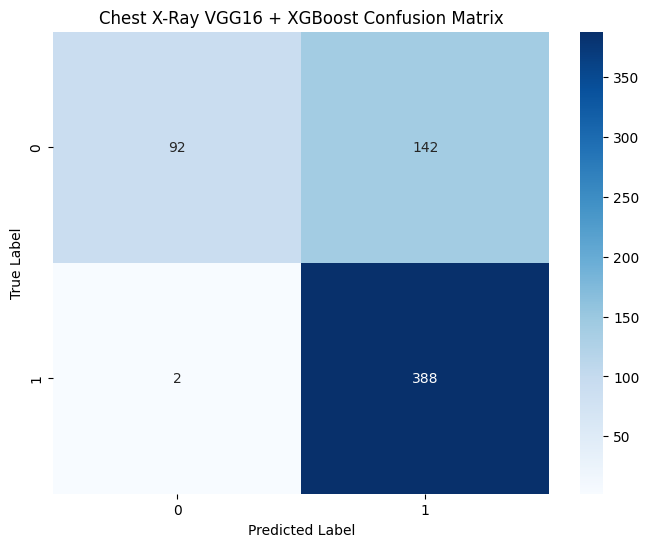

In [16]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Chest X-Ray VGG16 + XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Evaluation Metrics

The VGG16 + XGBoost model is evaluated using:

- Accuracy
- F1 Score
- Sensitivity (Recall)
- Specificity

These metrics provide a comprehensive assessment of classification performance using deep feature extraction.

In [17]:
f1 = f1_score(ytest, ytest_pred, average="weighted")

sensitivity = recall_score(
    ytest,
    ytest_pred,
    average="weighted"
)

cm = confusion_matrix(ytest, ytest_pred)

specificity_list = []

for i in range(len(cm)):

    tp = cm[i, i]

    fn = np.sum(cm[i, :]) - tp

    fp = np.sum(cm[:, i]) - tp

    tn = np.sum(cm) - (tp + fn + fp)

    specificity = tn / (tn + fp)

    specificity_list.append(specificity)

specificity = np.mean(specificity_list)

print(f"Accuracy    : {test_accuracy*100:.2f}%")
print(f"F1 Score    : {f1*100:.2f}%")
print(f"Sensitivity : {sensitivity*100:.2f}%")
print(f"Specificity : {specificity*100:.2f}%")

Accuracy    : 76.92%
F1 Score    : 73.75%
Sensitivity : 76.92%
Specificity : 69.40%


## Training Percentage Experiment

The effect of training data size on VGG16 + XGBoost performance is analyzed.

The model is trained using:

- 20% of training data
- 40% of training data
- 60% of training data
- 80% of training data

The resulting accuracies are compared to observe performance trends.

In [18]:
training_sizes = [0.2, 0.4, 0.6, 0.8]

xgb_train_scores = []
xgb_test_scores = []

for size in training_sizes:

    x_small, _, y_small, _ = train_test_split(
        xtrain_features,
        ytrain,
        train_size=size,
        random_state=10,
        stratify=ytrain
    )

    xgb_model = XGBClassifier(
        objective='binary:logistic',
        random_state=10,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )

    xgb_model.fit(x_small, y_small)

    train_acc = xgb_model.score(x_small, y_small)
    test_acc = xgb_model.score(xtest_features, ytest)

    xgb_train_scores.append(train_acc)
    xgb_test_scores.append(test_acc)

    print(f"\nTraining Size: {int(size*100)}%")
    print(f"Samples Used: {len(x_small)}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy : {test_acc:.4f}")


Training Size: 20%
Samples Used: 1043
Training Accuracy: 1.0000
Testing Accuracy : 0.7436

Training Size: 40%
Samples Used: 2086
Training Accuracy: 1.0000
Testing Accuracy : 0.7628

Training Size: 60%
Samples Used: 3129
Training Accuracy: 1.0000
Testing Accuracy : 0.7724

Training Size: 80%
Samples Used: 4172
Training Accuracy: 1.0000
Testing Accuracy : 0.7692


## Accuracy Visualization

The testing accuracies obtained using different training percentages are plotted to visualize the impact of training data size on VGG16 + XGBoost performance.

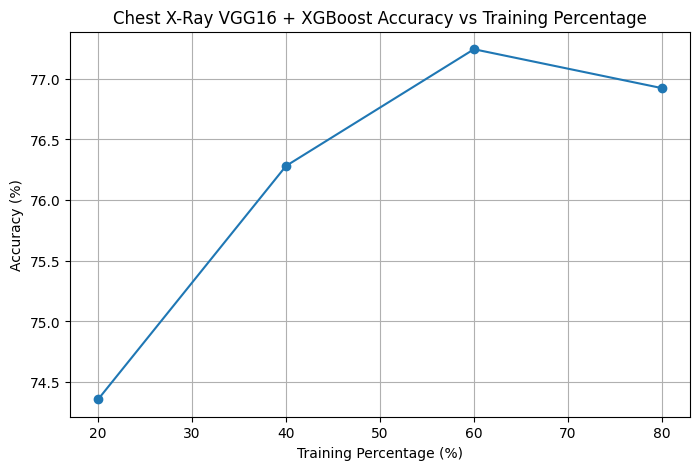

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    [20, 40, 60, 80],
    [x * 100 for x in xgb_test_scores],
    marker='o'
)

plt.title("Chest X-Ray VGG16 + XGBoost Accuracy vs Training Percentage")
plt.xlabel("Training Percentage (%)")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()